# Agentic RAG

RAG Agent는 Retriever를 Tool로 등록해서 Agent가 **검색 여부를 판단**한다. 하지만 검색 자체는 여전히 1회성이다. 검색 결과가 부정확해도 그대로 답변에 사용하고, 쿼리가 검색에 부적합해도 수정 없이 넘긴다.

Agentic RAG는 **검색 파이프라인 자체**를 에이전트화한다. 검색 결과를 평가하고, 부족하면 쿼리를 재작성해서 다시 검색하고, 답변 생성 후에도 자체 검증을 거친다. 즉, 검색 → 평가 → 재시도의 **자율적인 루프**를 구성하는 것이 핵심이다.

| 구분 | RAG Agent | Agentic RAG |
|----|-----------|-------------|
| 핵심 아이디어 | Agent가 RAG를 **도구로 사용** | RAG 흐름 자체가 **에이전트화** |
| 검색 횟수 | 보통 1회 | 필요에 따라 반복 |
| 자율성 | Agent 레벨에서 결정 (검색 여부) | 검색 레벨에서도 자율 판단 (쿼리 재작성, 관련성 평가) |
| 쿼리 수정 | 사용자 질문 그대로 | 동적으로 재작성 |
| 적합한 상황 | 단순 질문, 빠른 응답 | 복잡한 질문, 높은 정확도 |

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 실습: Agentic RAG 구현

Reflection 패턴의 "자기 평가 → 수정 → 재시도" 루프를 RAG 파이프라인에 적용한다.

구현할 그래프 구조:

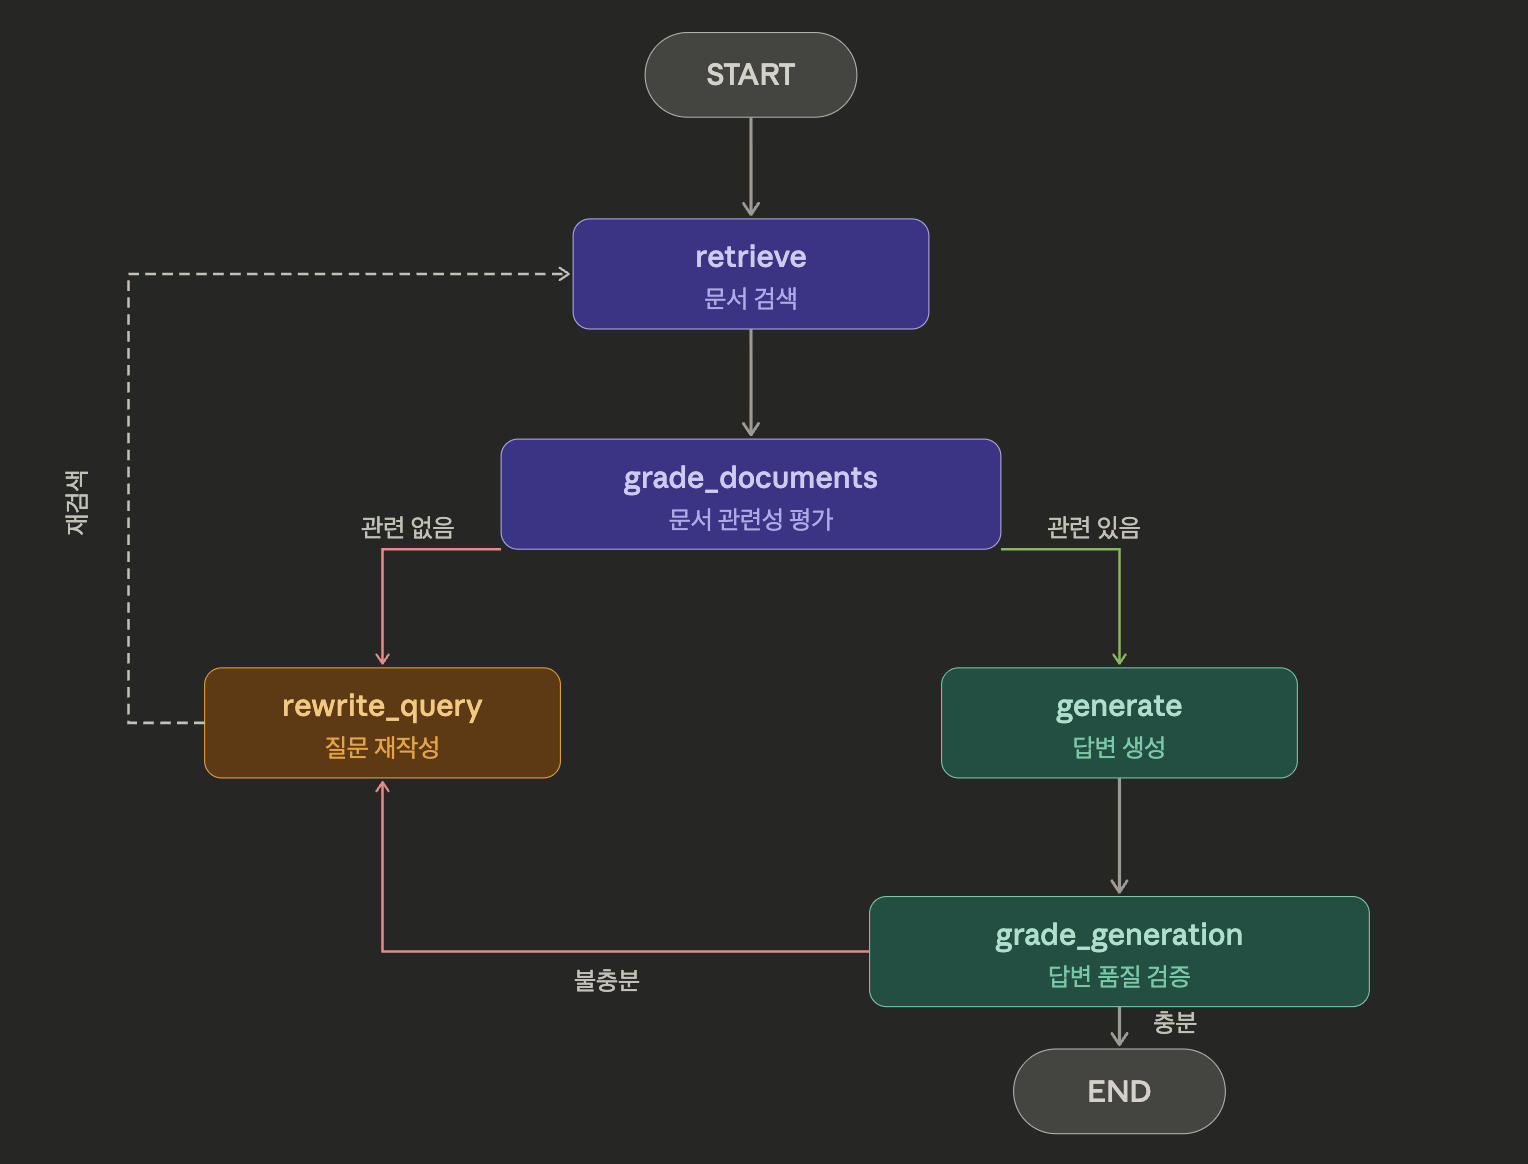

State 필드:
- `question`: 현재 질문 (재작성될 수 있음)
- `documents`: 검색된 문서
- `generation`: 생성된 답변
- `citations`: 답변의 근거가 된 문서 원문 발췌
- `relevance`: 문서 관련성 평가 결과 (bool)
- `is_sufficient`: 답변 품질 검증 결과 (bool)
- `retry_count`: 재시도 횟수 (무한 루프 방지)

In [5]:
# 벡터디비 생성
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import chromadb

COLLECTION_NAME = "agentic_rag"  # 컬렉션 이름 (RDB의 테이블에 해당)
PERSIST_DIR = "./chroma_db"  # 저장 폴더 경로 (RDB의 데이터베이스에 해당)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 문서 로드 → 분할
loader = PyPDFLoader("data/SPRi AI Brief_9월호_산업동향_0909_F.pdf")
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

print(f"총 {len(chunks)}개 청크를 벡터 DB에 저장합니다...")

# 기존 컬렉션이 있으면 삭제 (중복 방지)
client = chromadb.PersistentClient(path=PERSIST_DIR)
if COLLECTION_NAME in [c.name for c in client.list_collections()]:
    client.delete_collection(COLLECTION_NAME)

# 벡터 스토어 생성 + 문서 저장
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
    
)

print("저장 완료!")

# 유사도 검색
query = "즈푸 AI의 AI 모델 이름이 뭐야?"
results = vectorstore.similarity_search(query, k=3)

print(f"질문: {query}\n")
for i, doc in enumerate(results):
    print(f"--- 결과 {i+1} (페이지 {doc.metadata.get('page')}) ---")
    print(doc.page_content[:150])
    print()

총 108개 청크를 벡터 DB에 저장합니다...
저장 완료!
질문: 즈푸 AI의 AI 모델 이름이 뭐야?

--- 결과 1 (페이지 9) ---
£즈푸 AI의 GLM-4.5, 추론과 코딩, 에이전트 기능을 통합적으로 지원n중국 AI 기업 즈푸 AI(Zhipu AI)가 추론 기능을 갖춘 플래그십 AI 모델 ‘GLM-4.5’와 ‘GLM-4.5-Air’를 허깅페이스(Hugging Face)와 모델 스코프(ModelS

--- 결과 2 (페이지 9) ---
SPRi AI Brief2025년 9월호
8
즈푸 AI, 추론과 에이전트 성능 강화한 ‘GLM-4.5’ 공개n즈푸 AI가 하나의 모델로 추론과 코딩, 에이전트 기능을 모두 수행할 수 있도록 설계된 전문가 혼합(MOE) 구조의 플래그십 AI 모델 ‘GLM-4.5’와 ‘G

--- 결과 3 (페이지 14) ---
MCP 서버도 출시* AI 모델이 필요 정보를 외부 데이터 소스나 도구와 표준화 방식으로 주고받도록 하는 개방형 통신 규약£구글, 제미나이 2.5 프로의 고급 추론 기능을 활용한 AI 코딩 에이전트 ‘줄스’ 정식 출시n한편, 구글은 2024년 12월 처음 공개한 AI 



In [45]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

class State(TypedDict):
    question: str# 현재 질문 (재작성될 수 있음)
    documents: list # 검색된 문서
    generation: str # 생성된 답변
    citations: list # 답변의 근거가 된 문서 원문 발췌
    relevance: bool # 문서 관련성 평가 결과 (bool)
    is_sufficient: bool # 답변 품질 검증 결과 (bool)
    retry_count: int # 재시도 횟수 (무한 루프 방지)


retreiver = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 4, "fetch_k": 10},
)

# Structured Output에서는 일관된 결과를 위해 temperature=0이 적합하다
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def _format_docs_with_index(docs):
    """문서에 번호를 붙여 포매팅한다. 페이지 번호도 함께 표시하여 LLM이 참조할 수 있게 한다."""
    return "\n\n".join(
        f"[{i+1}] (페이지 {doc.metadata.get('page', '?')}) {doc.page_content}"
        for i, doc in enumerate(docs)
    )


# Node
def retreive(state: State):
    """질문을 받아다가 vector store에 검색"""
    print("[retriver]")
    question = state['question']
    docs = retreiver.invoke(question)
    
    return {"documents": docs,'retry_count' : state['retry_count'] + 1}

# grade docs
class GradeDocumentsResult(BaseModel):
    reason: str = Field(description="질문에 직접 답을 할 수 있는 정보가 있는지를 판단하는 근거")
    result: bool = Field(description="질문에 직접 답을 할 수 있는 정보가 있으면 True / 없으면 False")

grade_docs_llm = llm.with_structured_output(GradeDocumentsResult)

def grade_documents(state: State):
    """검색한 data를 바탕으로 우리의 question에 대답할 수 있는 질문인지 확인."""
    question = state['question']
    documents = state['documents']
    
    prompt = ChatPromptTemplate.from_messages([
    ("system", """
너는 검색결과가 질문과 관련성이 있는지를 판단하는 평가자야.
아래 문서가 question에 대해서 직접적으로 답변할 수 있는 구체적인 정보가 있는지 판단해줘.
# 판단 기준
     - 질문에 대한 구체적인 사실 / 수치 / 설명이 있으면 result : true
     - 비슷한 분야지만 다른 주제면 result : false
# 문서
{documents}
"""),
    ("human", "question : {question}"),
    ])

    chain = prompt | grade_docs_llm

    docs_text = _format_docs_with_index(documents)

    response = chain.invoke(
        {
            "documents" : docs_text,
            "question" : question
        }
    )
    print(f'[grade_documents] 판단 : {response.result} - {response.reason} ')
    return {"relevance" : response.result}

def generate(state: State):
    """검색한 data를 바탕으로 우리의 question에 답변한다."""
    question = state['question']
    documents = state['documents']
    
    prompt = ChatPromptTemplate.from_messages([
    ("system", """
다음 문서를 바탕으로 질문에 답변해라.
문서에 없는 내용은 추측하지 마라. 
문서에 근거한 내용만 답변해라.

# 문서
{documents}
"""),
    ("human", "질문 : {question}"),
    ])

    chain = prompt | llm

    docs_text = _format_docs_with_index(documents)

    response = chain.invoke(
        {
            "documents" : docs_text,
            "question" : question
        }
    )
    print("[generation] : 답변 생성됨. ")
    return {"generation" : response.content}


class GradeGenerationResult(BaseModel):
    reason: str = Field(description="답변이 문서를 기반으로 작성이 되어있는지 / 답변이 질문에 대해서 충분히 설명했는지를 판단하는 근거")
    result: bool = Field(description="답변이 문서를 기반으로 작성이 되어있는지 / 답변이 질문에 대해서 충분히 설명했는지 여부")

grade_generation_llm = llm.with_structured_output(GradeGenerationResult)

def grade_generation(state: State):
    """검색한 data를 바탕으로 생성된 generation이 data와 연관있는지 / 
    question에 대해 충분히 답변하는지 검증"""
    question = state['question']
    documents = state['documents']
    generation = state['generation']

    prompt = ChatPromptTemplate.from_messages([
    ("system", """
너는 답변에 대한 품질 검사자야.
1. 답변이 문서를 기반으로 작성이 되있으면 True / 문서 기반으로 작성이 되지 않았으면 False
2. 답변이 질문에 대해서 충분히 답변했으면 True / 질문에 대해 충분히 답변하지 않았으면 False

     
# 문서
{documents}
    
# 질문
{question}

"""),
    ("human", "답변 : {generation}"),
    ])

    chain = prompt | grade_generation_llm

    docs_text = _format_docs_with_index(documents)

    response = chain.invoke(
        {
            "documents" : docs_text,
            "question" : question,
            "generation" : generation
        }
    )
    print(f'[grade_generation] 판단 : {response.result} - {response.reason} ')
    return {"is_sufficient" : response.result}

def rewrite_query(state: State):
    question = state['question']

    prompt = ChatPromptTemplate.from_messages([
    ("system", """
embedding의 품질을 높이기 위해 다음 질문과 같은 의도의 다른 표현 질문을 작성해줘.
질문만 출력해.

"""),
    ("human", "질문 : {question}"),
    ])

    chain = prompt | llm
    result = chain.invoke({"question" : question})
    print('[rewrite]', result.content)
    return {'question' : result.content}


# routing function
def route_after_grade_documents(state: State):
    if state['relevance']:
        return "relevance"
    if state['retry_count'] >= 3:
        return "relevance"
    return "irrelevance"

def route_after_grade_generation(state: State):
    if state['is_sufficient']:
        return "is_sufficient"
    if state['retry_count'] >= 3:
        return "is_sufficient"
    return "is_not_sufficient"




In [46]:
# 그래프 생성
graph_builder = StateGraph(State)

# 노드 추가 (이름, 함수)
graph_builder.add_node("retreive",retreive ) # vector store에서 데이터 retreive
graph_builder.add_node("grade_documents", grade_documents) # 우리 질문과 가져온 데이터와의 정합성을 판단.
graph_builder.add_node("generate", generate) # 데이터를 바탕으로 질문에 대한 대답을 작성
graph_builder.add_node("grade_generation", grade_generation) # 작성한 응답을 바탕으로 우리 질문과 연관이 있는지 / 데이터에서 없는 내용이 있는지.
graph_builder.add_node("rewrite_query", rewrite_query) # 더 좋은 데이터를 가져오기 위한 질문 재작성.

# 엣지 추가
graph_builder.add_edge(START, "retreive")  # 시작 
graph_builder.add_edge("retreive", "grade_documents")
graph_builder.add_conditional_edges(
    "grade_documents",
    route_after_grade_documents,
    {
        "relevance" : "generate",
        "irrelevance" : "rewrite_query"
    }
)
graph_builder.add_edge("generate", "grade_generation")

graph_builder.add_conditional_edges(
    "grade_generation",
    route_after_grade_generation,
    {
        "is_sufficient" : END,
        "is_not_sufficient" : "rewrite_query"
    }
)

graph_builder.add_edge("rewrite_query", "retreive")   

# 컴파일
graph = graph_builder.compile()

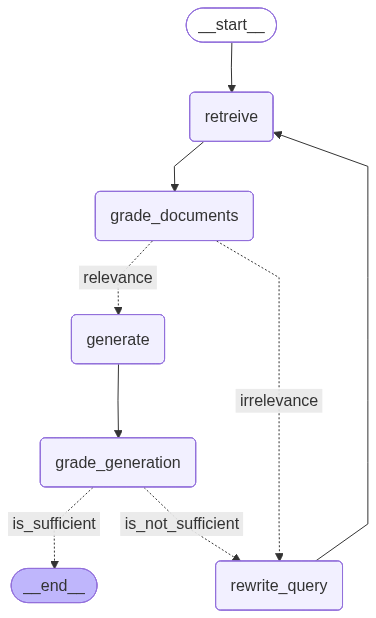

In [47]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:
# result = graph.invoke({"question" : "즈푸 ai는 뭐만들었어?", "retry_count" : 0})
result = graph.invoke({"question" : "배고픈데 밥 추천해줘", "retry_count" : 0})

[retriver]
[grade_documents] 판단 : False - 문서에는 음식 추천에 대한 구체적인 정보가 없고, 주로 AI 모델과 관련된 기술적 내용이 포함되어 있습니다. 
[rewrite] 배고픈데 어떤 음식을 먹으면 좋을지 추천해줄래?
[retriver]
[grade_documents] 판단 : False - 문서에는 음식 추천에 대한 구체적인 정보가 포함되어 있지 않으며, 배고픔을 해소하기 위한 음식에 대한 언급이 없습니다. 
[rewrite] 배고픈데 어떤 음식을 선택하면 좋을지 조언해줄 수 있어?
[retriver]
[grade_documents] 판단 : False - 문서에는 음식 선택에 대한 구체적인 정보나 조언이 포함되어 있지 않으며, 주로 AI 모델의 성능과 안전성에 대한 내용이 다루어지고 있습니다. 따라서 질문에 대한 직접적인 답변을 제공하지 않습니다. 
[generation] : 답변 생성됨. 
[grade_generation] 판단 : False - 답변이 문서를 기반으로 작성되지 않았으며, 질문에 대해 충분히 답변하지 않았습니다. 


In [49]:
print(result['generation'])

문서에는 음식 선택에 대한 조언을 제공하는 내용이 포함되어 있지 않습니다. 따라서 이 질문에 대한 답변을 드릴 수 없습니다.
